In [37]:
import pandas as pd

# Apni file ka exact naam yahan daalo
df = pd.read_csv('House Price Prediction Dataset.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
df.head()

Shape: (2000, 10)

Column names: ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [38]:
print("Data types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nPrice distribution:\n")
df['Price'].describe()

Data types:
 Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

Missing values:
 Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Price distribution:



,Price
count,2000.000000
mean,537676.855000
std,276428.845719
min,50005.000000
25%,300098.000000
50%,539254.000000
75%,780086.000000
max,999656.000000


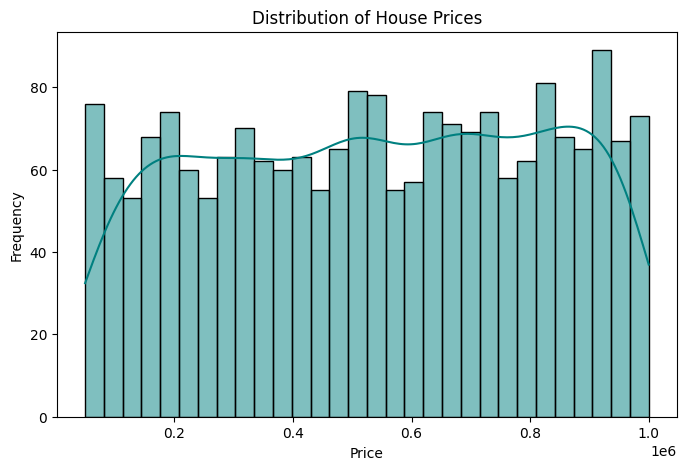

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True, color='teal')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

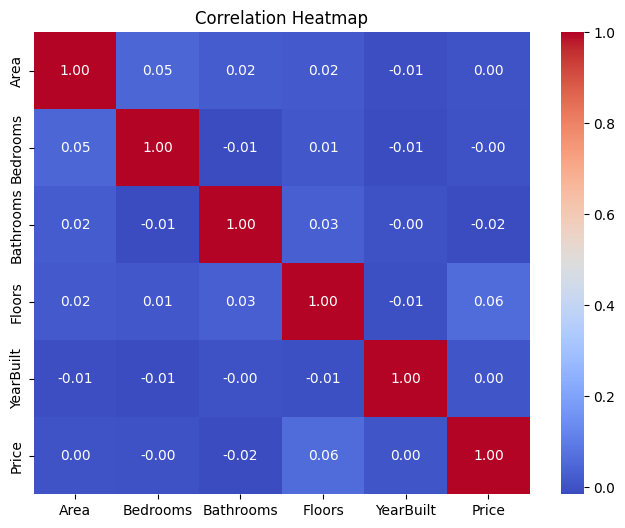

In [40]:
# Feature selection discussion — kaunse columns numeric predictors hain
# Location, Condition, Garage — ye categorical hain, inko encode karna padega

# Correlation heatmap (sirf numeric columns ke beech)
numeric_df = df[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Observation: Feature Selection & Correlation
Correlation heatmap dikhata hai ki koi bhi numeric feature (Area, Bedrooms,
Bathrooms, Floors, YearBuilt) Price ke saath meaningful correlation nahi
rakhta (saare values 0 ke bahut kareeb hain, -0.02 se 0.06 tak). Ye
suggest karta hai ki ye dataset synthetic/randomly generated hai, jisme
real-world housing market ka natural relationship (jaise bada area =
zyada price) reflect nahi hota.

In [41]:
# Location, Condition, Garage ko encode karo (text ko numbers mein badalna)
df_encoded = pd.get_dummies(df, columns=['Location', 'Condition', 'Garage'], drop_first=True)

print("Columns after encoding:\n", df_encoded.columns.tolist())
df_encoded.head()

Columns after encoding:
 ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features (X) aur Target (y) alag karo
X = df_encoded.drop(['Id', 'Price'], axis=1)
y = df_encoded['Price']

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model train karo
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 78321466146.0328
RMSE: 279859.72583784326
R² Score: -0.006717808430749761


### Observation: Model Performance
Model ka R² Score -0.007 hai, jo bilkul zero ke kareeb hai — matlab model
Price ko predict karne mein average se bhi better perform nahi kar raha.
Ye poor performance dataset mein weak feature-target correlation ki
wajah se hai, model ki galti nahi. Actual vs Predicted scatter plot bhi
confirm karta hai ki predictions ek narrow range mein clustered hain,
actual values ke saath align nahi hote.

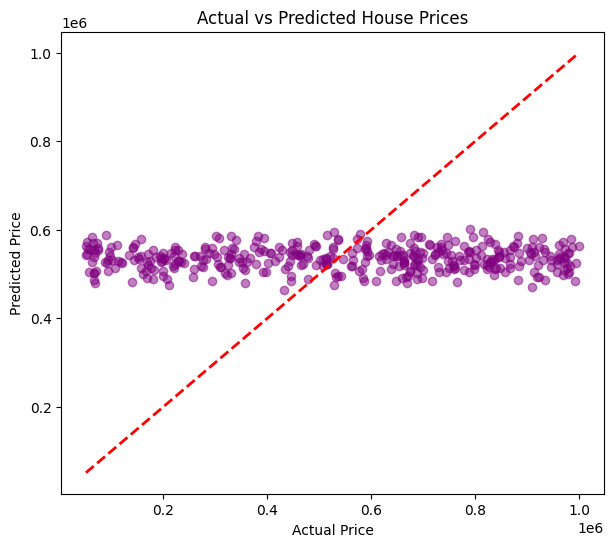

In [43]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

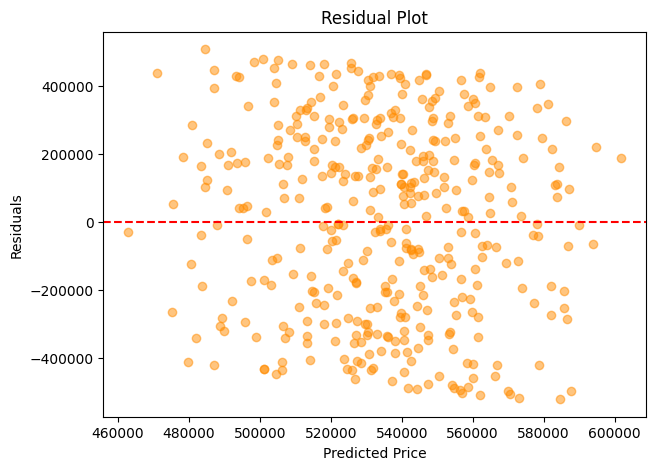

In [44]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.5, color='darkorange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [45]:
# Coefficient analysis — kaunse features Price ko sabse zyada impact karte hain
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

              Feature   Coefficient
8      Condition_Fair  24083.307846
3              Floors  23727.983633
6   Location_Suburban  11511.989815
10     Condition_Poor   4073.268930
11         Garage_Yes   2373.530579
5      Location_Rural   1317.542020
4           YearBuilt    117.613885
1            Bedrooms     76.784827
0                Area     -0.575754
2           Bathrooms  -9662.248234
7      Location_Urban -12718.918912
9      Condition_Good -12941.044835


### Observation: Coefficient Analysis
Coefficients bahut chhote aur inconsistent hain (Area ka coefficient
-0.58, jo practically zero hai). Sabse bada coefficient "Condition_Fair"
(24,083) hai, lekin ye bhi weak signal hai given the low R² score. Koi
feature dominant predictor nahi nikla.

## Conclusion

Is task mein humne ek house price dataset pe Linear Regression model
banaya — data cleaning, EDA, one-hot encoding, aur model training/
evaluation complete kiya. Model ka R² Score (-0.007) dikhata hai ki
is particular dataset mein features aur Price ke beech koi strong
statistical relationship nahi hai, jo synthetic data hone ki wajah
se ho sakta hai. Ye ek important learning hai: **har dataset predictable
nahi hota**, aur weak correlation ko identify karna (via EDA aur
correlation analysis) model banane se pehle hi ek zaroori step hai,
taaki galat expectations na ho. Real-world housing datasets mein
typically Area jaisa feature Price se strong correlation dikhata hai,
jo iss dataset mein absent hai.